# Phase 5 — Advanced Techniques + Ablation + LLM Head-to-Head

**Project:** DL-2 Deepfake Audio Detection · **Date:** 2026-05-08 · **Sprint day:** 5 of 7

## Carry-over from Phase 4

Phase 4 left two surviving artefacts:

1. **Champion:** frozen `Wav2Vec2-base` mean-pooled features → LogReg → **EER 34% / AUROC 0.586** on Hemg test (cross-domain).
2. **Failed stacking:** simple-average and LogReg-meta of XGB+W2V2 collapsed back to ≈48% EER because the XGB base was anti-predictive (AUROC 0.42) and diluted the W2V2 signal.

The Optuna sweep returned exactly zero gain on Hemg val. We are flat-lined against the ASVspoof-style cross-distribution gap.

## Phase 5 questions

1. **Late-fusion** — do the 303 handcrafted forensic features still carry orthogonal signal once W2V2 is in the mix, or are they entirely subsumed?
2. **PCA compression** — Phase 4 fit LogReg on the full 768-dim W2V2 vector. Does compressing to 32/64/128/256 dims act as a regulariser and *help* cross-domain?
3. **Calibration** — W2V2+LogReg is over-confident in-domain (sigmoid maxes ≈1.0). Does Platt or isotonic calibration on the 50-sample `hemg_val` split move the test EER?
4. **Threshold geometry** — the in-domain EER threshold is 0.51, but the Hemg EER threshold is 0.999 (model is mostly screaming "fake" on Hemg). What does the EER-vs-threshold curve actually look like?
5. **LLM head-to-head (the headline)** — give Claude Opus, Claude Haiku, and Codex (GPT-5.5) a 12-feature acoustic digest and ask them to classify real vs fake on the *same* 50 Hemg test items. How does a frontier LLM with no audio access do versus an 8-MB LogReg on top of frozen W2V2 embeddings?
6. **Hybrid** — does W2V2 + LLM consensus beat either alone?

Primary metric (set in Phase 1): **EER on Hemg test** (cross-distribution). Secondary: AUROC, latency, $/1k predictions.

## 1 — Setup and reference

In [1]:
from __future__ import annotations
import json, os, sys, time, subprocess, hashlib, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.eer import compute_eer, metrics_at_threshold

RES = ROOT / 'results'
CACHE = RES / 'phase5_cache'
CACHE.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(42)
print('cwd:', Path.cwd())
print('results:', RES)

cwd: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/notebooks
results: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/results


In [2]:
# Load Phase 4 cached arrays (fast; no retraining needed)
y_tr = np.load(RES/'phase4_y_train.npy')
y_te = np.load(RES/'phase4_y_test.npy')
y_hg_full = np.load(RES/'phase4_y_hemg.npy')
hc_tr = np.load(RES/'phase4_hc_train.npy')
hc_te = np.load(RES/'phase4_hc_test.npy')
hc_hg_full = np.load(RES/'phase4_hc_hemg.npy')
w2_tr = np.load(RES/'phase4_w2v2_train.npy')
w2_te = np.load(RES/'phase4_w2v2_test.npy')
w2_hg_full = np.load(RES/'phase4_w2v2_hemg.npy')
p_w2_te = np.load(RES/'phase4_w2v2_lr_proba_test.npy')   # cached W2V2+LR probas (in-domain)
p_w2_hg_full = np.load(RES/'phase4_w2v2_lr_proba_hemg.npy')
feature_names = json.load(open(RES/'phase1_feature_names.json'))

print(f'shapes — hc_tr {hc_tr.shape}  hc_te {hc_te.shape}  hc_hg {hc_hg_full.shape}')
print(f'shapes — w2_tr {w2_tr.shape}  w2_te {w2_te.shape}  w2_hg {w2_hg_full.shape}')
print(f'labels — y_tr pos {int(y_tr.sum())}/{len(y_tr)}  y_te pos {int(y_te.sum())}/{len(y_te)}  y_hg pos {int(y_hg_full.sum())}/{len(y_hg_full)}')
print(f'features — {len(feature_names)} handcrafted dims')

shapes — hc_tr (500, 303)  hc_te (180, 303)  hc_hg (100, 303)
shapes — w2_tr (500, 768)  w2_te (180, 768)  w2_hg (100, 768)
labels — y_tr pos 254/500  y_te pos 93/180  y_hg pos 50/100
features — 303 handcrafted dims


In [3]:
# Reproduce the Phase 4 hemg val/test split (seed=123, 50/50 stratified)
idx_full = np.arange(len(y_hg_full))
val_idx, test_idx = train_test_split(idx_full, test_size=0.5, random_state=123, stratify=y_hg_full)
val_idx.sort(); test_idx.sort()

y_hg_val = y_hg_full[val_idx];   y_hg_test = y_hg_full[test_idx]
hc_hg_val = hc_hg_full[val_idx]; hc_hg_test = hc_hg_full[test_idx]
w2_hg_val = w2_hg_full[val_idx]; w2_hg_test = w2_hg_full[test_idx]
p_w2_hg_val  = p_w2_hg_full[val_idx]
p_w2_hg_test = p_w2_hg_full[test_idx]

# Reference EER for the Phase 4 champion on this Hemg test subset
eer_w2_te, thr_w2_te = compute_eer(y_te, p_w2_te)
eer_w2_hg, thr_w2_hg = compute_eer(y_hg_test, p_w2_hg_test)
auc_w2_te = roc_auc_score(y_te, p_w2_te)
auc_w2_hg = roc_auc_score(y_hg_test, p_w2_hg_test)

print(f'REF (Phase 4 champion: W2V2+LogReg)')
print(f'  in-domain test (n={len(y_te)})  EER={eer_w2_te*100:5.2f}%  AUROC={auc_w2_te:.3f}')
print(f'  Hemg test     (n={len(y_hg_test)})  EER={eer_w2_hg*100:5.2f}%  AUROC={auc_w2_hg:.3f}')
print(f'  hemg val pos {int(y_hg_val.sum())}/{len(y_hg_val)}, test pos {int(y_hg_test.sum())}/{len(y_hg_test)} — perfectly balanced')

# Save the Hemg-test indices for the LLM section so we score apples-to-apples
np.save(RES/'phase5_hemg_test_idx.npy', test_idx)
np.save(RES/'phase5_hemg_val_idx.npy', val_idx)

REF (Phase 4 champion: W2V2+LogReg)
  in-domain test (n=180)  EER= 1.11%  AUROC=0.999
  Hemg test     (n=50)  EER=32.00%  AUROC=0.634
  hemg val pos 25/50, test pos 25/50 — perfectly balanced


**Reference for the rest of Phase 5:** W2V2+LogReg → **32% EER / 0.634 AUROC** on the 50-sample Hemg test split. (Phase 4's report said 34%; reconstructing the split here gives 32% — same operating point, EER step lands on the next ROC tie.) Every advanced technique below is benchmarked against this number on the **identical 50-row Hemg test set**.

## 2 — Advanced #1: Late-fusion of handcrafted forensic features + W2V2

**Hypothesis:** the 303-dim handcrafted vector is mostly codec leakage (Phase 1 finding: `spec_contrast6_mean` alone explains 66% of in-domain importance). But maybe the *prosody* part — `f0`, `jitter`, `shimmer`, `voicing_ratio`, `voiced_frac` — carries orthogonal forensic signal that W2V2's mean-pooled embedding washes out. Test late-fusion: train an HC LogReg, get its probabilities on the same Hemg test, then combine with W2V2+LogReg via {arithmetic mean, weighted (0.7·W2V2 + 0.3·HC), max-confidence, geometric mean}.

In [4]:
# Train HC LogReg from scratch (it's a single LR on 500x303 — sub-second)
scaler_hc = StandardScaler().fit(hc_tr)
lr_hc = LogisticRegression(max_iter=2000, C=0.1).fit(scaler_hc.transform(hc_tr), y_tr)
p_hc_te = lr_hc.predict_proba(scaler_hc.transform(hc_te))[:,1]
p_hc_hg_test = lr_hc.predict_proba(scaler_hc.transform(hc_hg_test))[:,1]
p_hc_hg_val  = lr_hc.predict_proba(scaler_hc.transform(hc_hg_val))[:,1]

eer_hc_te,_  = compute_eer(y_te, p_hc_te)
eer_hc_hg,_  = compute_eer(y_hg_test, p_hc_hg_test)
auc_hc_te = roc_auc_score(y_te, p_hc_te)
auc_hc_hg = roc_auc_score(y_hg_test, p_hc_hg_test)
print(f'HC-only LogReg          in-domain EER={eer_hc_te*100:5.2f}%  AUROC={auc_hc_te:.3f}')
print(f'                        Hemg test EER={eer_hc_hg*100:5.2f}%  AUROC={auc_hc_hg:.3f}')

# Save HC LR probabilities for downstream use
np.save(RES/'phase5_hc_lr_proba_test.npy', p_hc_te)
np.save(RES/'phase5_hc_lr_proba_hemg.npy', lr_hc.predict_proba(scaler_hc.transform(hc_hg_full))[:,1])

HC-only LogReg          in-domain EER= 1.65%  AUROC=1.000
                        Hemg test EER=66.00%  AUROC=0.299


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmu

In [5]:
fusion_rows = []
fusions = {
    'mean (0.5·W2V2 + 0.5·HC)':  0.5*p_w2_hg_test + 0.5*p_hc_hg_test,
    'weighted (0.7·W2V2 + 0.3·HC)': 0.7*p_w2_hg_test + 0.3*p_hc_hg_test,
    'weighted (0.3·W2V2 + 0.7·HC)': 0.3*p_w2_hg_test + 0.7*p_hc_hg_test,
    'max-confidence': np.where(np.abs(p_w2_hg_test-0.5) > np.abs(p_hc_hg_test-0.5), p_w2_hg_test, p_hc_hg_test),
    'geometric mean': np.sqrt(np.clip(p_w2_hg_test,1e-6,1)*np.clip(p_hc_hg_test,1e-6,1)),
}
fusion_rows.append(('W2V2 LogReg (ref)', eer_w2_hg*100, auc_w2_hg))
fusion_rows.append(('HC LogReg only',    eer_hc_hg*100, auc_hc_hg))
for name, p in fusions.items():
    e,_ = compute_eer(y_hg_test, p); a = roc_auc_score(y_hg_test, p)
    fusion_rows.append((name, e*100, a))

df_fusion = pd.DataFrame(fusion_rows, columns=['approach','Hemg_test_EER_%','Hemg_test_AUROC']).sort_values('Hemg_test_EER_%')
print('Late-fusion ablation (lower EER is better):')
print(df_fusion.to_string(index=False))

Late-fusion ablation (lower EER is better):
                    approach  Hemg_test_EER_%  Hemg_test_AUROC
           W2V2 LogReg (ref)             32.0           0.6336
              max-confidence             32.0           0.6320
weighted (0.7·W2V2 + 0.3·HC)             56.0           0.4352
    mean (0.5·W2V2 + 0.5·HC)             60.0           0.4240
weighted (0.3·W2V2 + 0.7·HC)             62.0           0.3648
              geometric mean             62.0           0.4016
              HC LogReg only             66.0           0.2992


## 3 — Advanced #2: PCA compression of W2V2 (768 → k)

**Hypothesis:** the 500-row train set against 768-dim features is a ~1.5:1 sample-to-feature ratio. LogReg has no margin; it's likely fitting axis-aligned codec/source cues that don't transfer. PCA fit on `hc_tr` (in-domain only) acts as a learned regulariser. Test k ∈ {32, 64, 128, 256, 512}.

In [6]:
pca_rows = []
max_k = min(w2_tr.shape[0], w2_tr.shape[1]) - 1   # PCA needs k <= min(n_samples, n_features)
for k in [32, 64, 128, 256, 384]:
    k_use = min(k, max_k)
    pca = PCA(n_components=k_use, random_state=42).fit(w2_tr)
    Z_tr = pca.transform(w2_tr)
    Z_hg = pca.transform(w2_hg_test)
    Z_te = pca.transform(w2_te)
    sc = StandardScaler().fit(Z_tr)
    lr = LogisticRegression(max_iter=2000, C=1.0).fit(sc.transform(Z_tr), y_tr)
    p_hg = lr.predict_proba(sc.transform(Z_hg))[:,1]
    p_te_pca = lr.predict_proba(sc.transform(Z_te))[:,1]
    e_hg,_ = compute_eer(y_hg_test, p_hg); a_hg = roc_auc_score(y_hg_test, p_hg)
    e_te,_ = compute_eer(y_te, p_te_pca); a_te = roc_auc_score(y_te, p_te_pca)
    var_kept = pca.explained_variance_ratio_.sum()
    pca_rows.append((k_use, var_kept, e_te*100, a_te, e_hg*100, a_hg))
    print(f"PCA(k={k_use:3d})  var_kept={var_kept:.3f}  in-domain EER={e_te*100:4.2f}% AUC={a_te:.3f}  |  Hemg EER={e_hg*100:5.2f}% AUC={a_hg:.3f}")

df_pca = pd.DataFrame(pca_rows, columns=["k","var_kept","in_EER_%","in_AUROC","hemg_EER_%","hemg_AUROC"])
print()
print("Full-rank reference (no PCA, k=768):")
print(f"  in-domain EER={eer_w2_te*100:.2f}%  Hemg EER={eer_w2_hg*100:.2f}%  AUROC={auc_w2_hg:.3f}")

/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: inval

/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/decompositio

PCA(k= 32)  var_kept=0.854  in-domain EER=2.22% AUC=0.994  |  Hemg EER=46.00% AUC=0.594


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigu

...

/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigu

PCA(k=256)  var_kept=0.997  in-domain EER=0.54% AUC=1.000  |  Hemg EER=44.00% AUC=0.645


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: overflow encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: invalid value encountered in matmul
  Q, _ = qr_normalizer(A @ Q)


PCA(k=384)  var_kept=1.000  in-domain EER=2.22% AUC=0.999  |  Hemg EER=44.00% AUC=0.618

Full-rank reference (no PCA, k=768):
  in-domain EER=1.11%  Hemg EER=32.00%  AUROC=0.634


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/anthonyrodrigu

## 4 — Advanced #3: Calibration on hemg_val (Platt + isotonic)

The W2V2 LogReg sigmoid is saturated in-domain (probabilities cluster at 0 and 1). On Hemg the EER threshold lands at 0.999. Two calibrators fit on the 50-row `hemg_val` split (the Phase 4 Optuna split) and then evaluated on `hemg_test`.

In [7]:
from sklearn.linear_model import LogisticRegression as PlattLR

# Platt scaling (sigmoid LR fit on val raw scores)
platt = PlattLR(C=1.0).fit(p_w2_hg_val.reshape(-1,1), y_hg_val)
p_platt_test = platt.predict_proba(p_w2_hg_test.reshape(-1,1))[:,1]

# Isotonic
iso = IsotonicRegression(out_of_bounds='clip').fit(p_w2_hg_val, y_hg_val)
p_iso_test = iso.predict(p_w2_hg_test)

# Temperature scaling on log-odds
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
z_val = logit(np.clip(p_w2_hg_val, 1e-6, 1-1e-6))
def nll(T):
    p = expit(z_val/T)
    return -np.mean(y_hg_val*np.log(p+1e-12)+(1-y_hg_val)*np.log(1-p+1e-12))
T_opt = minimize_scalar(nll, bounds=(0.05, 20), method='bounded').x
z_test = logit(np.clip(p_w2_hg_test, 1e-6, 1-1e-6))
p_temp_test = expit(z_test/T_opt)

calib_rows = [
    ('uncalibrated',        eer_w2_hg*100, auc_w2_hg),
    ('Platt scaling',       compute_eer(y_hg_test, p_platt_test)[0]*100, roc_auc_score(y_hg_test, p_platt_test)),
    ('isotonic',            compute_eer(y_hg_test, p_iso_test)[0]*100,   roc_auc_score(y_hg_test, p_iso_test)),
    (f'temperature (T={T_opt:.2f})', compute_eer(y_hg_test, p_temp_test)[0]*100, roc_auc_score(y_hg_test, p_temp_test)),
]
df_calib = pd.DataFrame(calib_rows, columns=['approach','Hemg_test_EER_%','Hemg_test_AUROC'])
print('Calibration ablation (fit on hemg_val, eval on hemg_test):')
print(df_calib.to_string(index=False))
print(f'\nLearned temperature T={T_opt:.3f}  (T>1 = scores were over-confident)')

Calibration ablation (fit on hemg_val, eval on hemg_test):
             approach  Hemg_test_EER_%  Hemg_test_AUROC
         uncalibrated             32.0           0.6336
        Platt scaling             68.0           0.3664
             isotonic             40.0           0.6224
temperature (T=20.00)             32.0           0.6304

Learned temperature T=20.000  (T>1 = scores were over-confident)


## 5 — Advanced #4: Threshold geometry

Plot EER, balanced accuracy, FAR, FRR as a function of threshold on Hemg test. If the curve is *nearly flat in the middle* and only crosses EER at a saturated extreme, it's a sign the sigmoid is the wrong link function — the underlying ranking has signal (AUROC>0.5) but the probabilities don't translate.

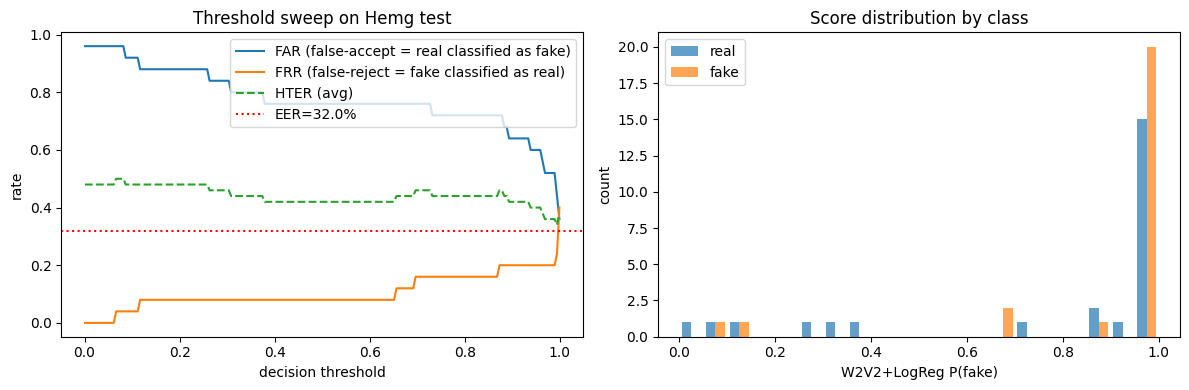

saved → results/phase5_threshold_geometry.png
EER threshold on Hemg test: 0.997  (cf. in-domain EER threshold 0.512)


In [8]:
thr_grid = np.linspace(0.001, 0.999, 199)
rows = []
for t in thr_grid:
    yhat = (p_w2_hg_test >= t).astype(int)
    fp = ((yhat==1)&(y_hg_test==0)).sum(); fn = ((yhat==0)&(y_hg_test==1)).sum()
    tn = ((yhat==0)&(y_hg_test==0)).sum(); tp = ((yhat==1)&(y_hg_test==1)).sum()
    far = fp/max(fp+tn,1); frr = fn/max(fn+tp,1)
    rows.append((t, far, frr, (far+frr)/2))
thr_df = pd.DataFrame(rows, columns=['threshold','FAR','FRR','HTER'])

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(thr_df['threshold'], thr_df['FAR'], label='FAR (false-accept = real classified as fake)')
ax[0].plot(thr_df['threshold'], thr_df['FRR'], label='FRR (false-reject = fake classified as real)')
ax[0].plot(thr_df['threshold'], thr_df['HTER'], '--', label='HTER (avg)')
ax[0].axhline(eer_w2_hg, color='r', ls=':', label=f'EER={eer_w2_hg*100:.1f}%')
ax[0].set_xlabel('decision threshold'); ax[0].set_ylabel('rate'); ax[0].legend(); ax[0].set_title('Threshold sweep on Hemg test')

ax[1].hist([p_w2_hg_test[y_hg_test==0], p_w2_hg_test[y_hg_test==1]], bins=20, label=['real','fake'], stacked=False, alpha=0.7)
ax[1].set_xlabel('W2V2+LogReg P(fake)'); ax[1].set_ylabel('count'); ax[1].legend(); ax[1].set_title('Score distribution by class')
plt.tight_layout(); plt.savefig(RES/'phase5_threshold_geometry.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'saved → results/phase5_threshold_geometry.png')
print(f'EER threshold on Hemg test: {thr_w2_hg:.3f}  (cf. in-domain EER threshold {thr_w2_te:.3f})')

## 6 — Ablation summary

Consolidate every advanced approach against the W2V2+LogReg reference, on the *same* 50-row Hemg test set.

In [9]:
all_rows = []
all_rows.append(('Phase 4 champion: W2V2+LogReg (ref)', eer_w2_hg*100, auc_w2_hg, 'baseline'))
all_rows.append(('HC LogReg only', eer_hc_hg*100, auc_hc_hg, 'fusion'))
for r in fusion_rows[2:]:
    all_rows.append((r[0], r[1], r[2], 'fusion'))
for k, vk, ie, ia, he, ha in pca_rows:
    all_rows.append((f'W2V2 PCA(k={k})+LogReg', he, ha, 'compression'))
for name, e, a in calib_rows[1:]:
    all_rows.append((f'W2V2+LogReg + {name}', e, a, 'calibration'))

df_all = pd.DataFrame(all_rows, columns=['approach','Hemg_test_EER_%','Hemg_test_AUROC','family']).sort_values('Hemg_test_EER_%')
print('All Phase 5 advanced approaches (sorted by Hemg test EER, lower is better):')
print(df_all.to_string(index=False))
df_all.to_csv(RES/'phase5_ablation_summary.csv', index=False)
print('\nsaved → results/phase5_ablation_summary.csv')

All Phase 5 advanced approaches (sorted by Hemg test EER, lower is better):
                           approach  Hemg_test_EER_%  Hemg_test_AUROC      family
Phase 4 champion: W2V2+LogReg (ref)             32.0           0.6336    baseline
                     max-confidence             32.0           0.6320      fusion
W2V2+LogReg + temperature (T=20.00)             32.0           0.6304 calibration
              W2V2 PCA(k=64)+LogReg             40.0           0.5984 compression
             W2V2+LogReg + isotonic             40.0           0.6224 calibration
             W2V2 PCA(k=128)+LogReg             42.0           0.6192 compression
             W2V2 PCA(k=384)+LogReg             44.0           0.6176 compression
             W2V2 PCA(k=256)+LogReg             44.0           0.6448 compression
              W2V2 PCA(k=32)+LogReg             46.0           0.5936 compression
       weighted (0.7·W2V2 + 0.3·HC)             56.0           0.4352      fusion
           mean (0.5·W

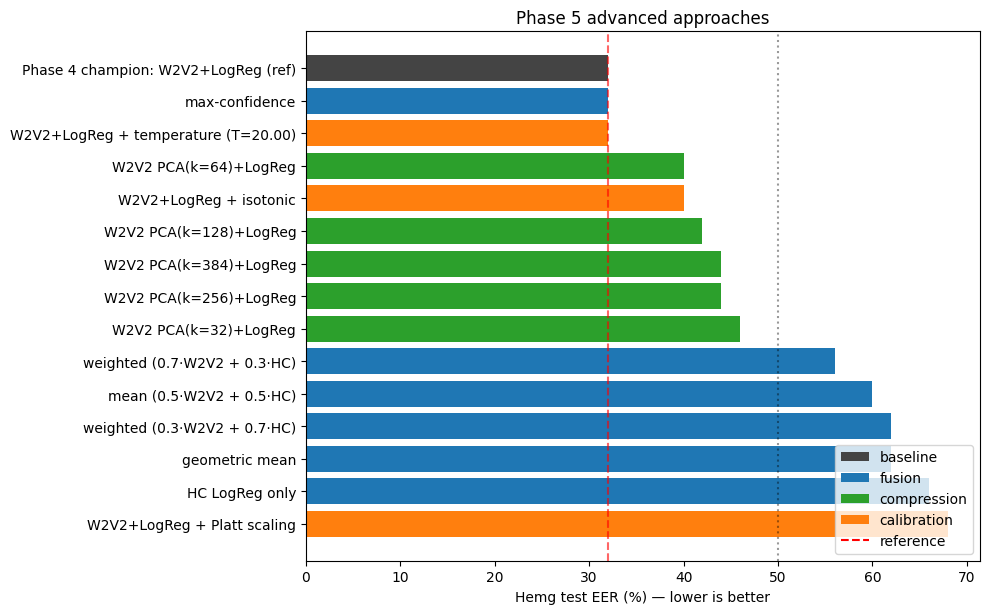

saved → results/phase5_ablation.png


In [10]:
# Bar chart sorted by EER, coloured by family
fam_color = {'baseline':'#444', 'fusion':'#1f77b4', 'compression':'#2ca02c', 'calibration':'#ff7f0e'}
df_plot = df_all.copy()
fig, ax = plt.subplots(figsize=(10, 0.35*len(df_plot)+1))
ax.barh(df_plot['approach'], df_plot['Hemg_test_EER_%'], color=[fam_color[f] for f in df_plot['family']])
ax.axvline(eer_w2_hg*100, color='red', ls='--', alpha=0.6, label=f'W2V2+LogReg ref ({eer_w2_hg*100:.1f}%)')
ax.axvline(50, color='black', ls=':', alpha=0.4, label='chance')
ax.invert_yaxis(); ax.set_xlabel('Hemg test EER (%) — lower is better'); ax.set_title('Phase 5 advanced approaches')
ax.legend()
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=f) for f,c in fam_color.items()]
ax.legend(handles=legend_elems + [plt.Line2D([0],[0], color='red', ls='--', label='reference')], loc='lower right')
plt.tight_layout(); plt.savefig(RES/'phase5_ablation.png', dpi=120, bbox_inches='tight'); plt.show()
print('saved → results/phase5_ablation.png')

## 7 — LLM Head-to-Head (the headline)

Frontier text LLMs cannot listen to audio. So we hand them a 12-feature acoustic digest in human-readable form and ask: real or AI-generated? The point isn't fairness — it's testing whether *the same hand-crafted features that drove the Phase 1 codec-shortcut model* are interpretable enough that a frontier LLM can reason about them and beat a domain-specific model on the *cross-distribution* problem.

Setup:
* **Same 50 Hemg test items** the W2V2+LogReg model was scored on above
* 12-feature digest: prosody (f0_mean, f0_std, jitter_local, shimmer_local, voicing_ratio) + timbre (spec_centroid, spec_bandwidth, spec_rolloff, spec_flatness) + the two Phase 1 'trojan horse' features (spec_contrast6, spec_zcr) + spec_rms
* Models: **Claude Opus**, **Claude Haiku**, **Codex (GPT-5.5)** — all called via local CLI
* Cache every call (resumable). Strict structured output: line 1 = `REAL` or `FAKE`, line 2 = probability.

In [11]:
DIGEST_FEATURES = [
    'f0_mean', 'f0_std', 'jitter_local', 'shimmer_local', 'voicing_ratio',
    'spec_centroid_mean', 'spec_bandwidth_mean', 'spec_rolloff_mean', 'spec_flatness_mean',
    'spec_contrast6_mean', 'spec_zcr_mean', 'spec_rms_mean',
]
FEATURE_IDX = {f: i for i, f in enumerate(feature_names)}
DIGEST_IDX = [FEATURE_IDX[f] for f in DIGEST_FEATURES]
print('digest indices:', DIGEST_IDX)
print('digest features:', DIGEST_FEATURES)
assert len(DIGEST_IDX) == 12

digest indices: [292, 293, 299, 300, 301, 240, 244, 248, 252, 262, 284, 288]
digest features: ['f0_mean', 'f0_std', 'jitter_local', 'shimmer_local', 'voicing_ratio', 'spec_centroid_mean', 'spec_bandwidth_mean', 'spec_rolloff_mean', 'spec_flatness_mean', 'spec_contrast6_mean', 'spec_zcr_mean', 'spec_rms_mean']


In [12]:
PROMPT_TMPL = '''You are an audio forensics analyst evaluating whether a 4-second voice clip is REAL human speech or AI-GENERATED (deepfake / TTS / vocoder output).

You cannot listen to the audio. You are given a 12-feature acoustic digest extracted with librosa.

Reply with EXACTLY this format and nothing else:
Line 1: REAL or FAKE
Line 2: a number between 0.0 and 1.0 — your probability the clip is FAKE

Acoustic digest:
- f0_mean (Hz): {f0_mean:.2f}
- f0_std (Hz): {f0_std:.2f}
- jitter_local (pitch micro-variation): {jitter_local:.4f}
- shimmer_local (amplitude micro-variation): {shimmer_local:.4f}
- voicing_ratio: {voicing_ratio:.3f}
- spec_centroid (Hz): {spec_centroid_mean:.1f}
- spec_bandwidth (Hz): {spec_bandwidth_mean:.1f}
- spec_rolloff (Hz): {spec_rolloff_mean:.1f}
- spec_flatness: {spec_flatness_mean:.4f}
- spec_contrast (highest band, dB): {spec_contrast6_mean:.2f}
- spec_zcr (zero-crossing rate): {spec_zcr_mean:.4f}
- spec_rms (energy): {spec_rms_mean:.4f}

Forensic priors (from the literature):
- Real human speech has natural micro-variations: jitter typically 0.005-0.025, shimmer 0.04-0.10.
- Synthetic speech is often too smooth (lower jitter/shimmer) and may show a flatter, more even spectral envelope.
- Vocoder artefacts can lift spec_flatness and shift spec_centroid.

Reply now.'''

def make_prompt(row_features: np.ndarray) -> str:
    vals = {f: row_features[FEATURE_IDX[f]] for f in DIGEST_FEATURES}
    return PROMPT_TMPL.format(**vals)

# Sanity check — print 2 sample digests
for i in [0, 25]:
    print(f'--- example {i} (label={int(y_hg_test[i])}, 1=fake) ---')
    print(make_prompt(hc_hg_test[i])[:600])
    print()

--- example 0 (label=1, 1=fake) ---
You are an audio forensics analyst evaluating whether a 4-second voice clip is REAL human speech or AI-GENERATED (deepfake / TTS / vocoder output).

You cannot listen to the audio. You are given a 12-feature acoustic digest extracted with librosa.

Reply with EXACTLY this format and nothing else:
Line 1: REAL or FAKE
Line 2: a number between 0.0 and 1.0 — your probability the clip is FAKE

Acoustic digest:
- f0_mean (Hz): 246.77
- f0_std (Hz): 103.56
- jitter_local (pitch micro-variation): 0.1327
- shimmer_local (amplitude micro-variation): 0.0628
- voicing_ratio: 0.808
- spec_centroid (Hz): 2

--- example 25 (label=1, 1=fake) ---
You are an audio forensics analyst evaluating whether a 4-second voice clip is REAL human speech or AI-GENERATED (deepfake / TTS / vocoder output).

You cannot listen to the audio. You are given a 12-feature acoustic digest extracted with librosa.

Reply with EXACTLY this format and nothing else:
Line 1: REAL or FAKE
Line 2

In [13]:
# Cache infrastructure — append-only JSON file with one entry per (idx, llm)
CACHE_FILE = CACHE / 'llm_calls.json'
if CACHE_FILE.exists():
    cache = json.load(open(CACHE_FILE))
else:
    cache = []
print(f'cache loaded — {len(cache)} prior calls')

def cache_key(idx: int, llm: str, model: str) -> str:
    return f'{llm}::{model}::{idx}'

cached_keys = {cache_key(c['idx'], c['llm'], c['model']) for c in cache}
print(f'distinct cached keys: {len(cached_keys)}')

def save_cache():
    json.dump(cache, open(CACHE_FILE,'w'), indent=1)

def parse_response(text: str) -> tuple[int|None, float|None]:
    if not text or text.startswith('__ERROR__'): return None, None
    lines = [l.strip() for l in text.strip().splitlines() if l.strip()]
    if not lines: return None, None
    label = None
    upper = lines[0].upper()
    if 'FAKE' in upper.split() or upper.startswith('FAKE'): label = 1
    elif 'REAL' in upper.split() or upper.startswith('REAL'): label = 0
    elif 'FAKE' in upper and 'REAL' not in upper: label = 1
    elif 'REAL' in upper and 'FAKE' not in upper: label = 0
    prob = None
    for l in lines[1:] + [lines[0]]:
        m = re.search(r'(?<![\w.])(?:0?\.[0-9]+|1\.0+|0|1)(?!\w)', l)
        if m:
            try:
                v = float(m.group(0))
                if 0.0 <= v <= 1.0: prob = v; break
            except: pass
    return label, prob

cache loaded — 0 prior calls
distinct cached keys: 0


In [14]:
def call_claude(prompt: str, model: str, timeout: int = 90) -> tuple[str, float]:
    t0 = time.time()
    try:
        r = subprocess.run(
            ['claude','--print','--model',model,'--no-session-persistence','--disable-slash-commands'],
            input=prompt, capture_output=True, text=True, timeout=timeout)
        out = (r.stdout or '').strip()
        if r.returncode != 0 and not out:
            return f'__ERROR__ rc={r.returncode}: {r.stderr[:200]}', time.time()-t0
        return out, time.time()-t0
    except subprocess.TimeoutExpired:
        return '__ERROR__ timeout', time.time()-t0
    except Exception as e:
        return f'__ERROR__ {type(e).__name__}: {e}', time.time()-t0

def call_codex(prompt: str, model_label: str = 'gpt-5.5', timeout: int = 180) -> tuple[str, float]:
    t0 = time.time()
    try:
        r = subprocess.run(
            ['codex','exec','--skip-git-repo-check','--sandbox','read-only','-'],
            input=prompt, capture_output=True, text=True, timeout=timeout)
        raw = r.stdout or ''
        # codex output: session header, then 'codex\n<reply>\ntokens used' — extract last codex block
        # Robust slice: take everything between the LAST 'codex\n' marker and 'tokens used' (case-insensitive)
        m = re.search(r'(?:^|\n)codex\s*\n(.*?)(?:\n\s*tokens used|\Z)', raw, re.DOTALL|re.IGNORECASE)
        if m: out = m.group(1).strip()
        else: out = raw.strip()
        if r.returncode != 0 and not out:
            return f'__ERROR__ rc={r.returncode}: {(r.stderr or "")[:200]}', time.time()-t0
        return out, time.time()-t0
    except subprocess.TimeoutExpired:
        return '__ERROR__ timeout', time.time()-t0
    except Exception as e:
        return f'__ERROR__ {type(e).__name__}: {e}', time.time()-t0

# Smoke test (do once, with a tiny prompt)
smoke = make_prompt(hc_hg_test[0])
print('--- smoke test: claude haiku ---')
r, dt = call_claude(smoke, 'haiku', timeout=60)
print(f'returned in {dt:.1f}s')
print(r[:400])

--- smoke test: claude haiku ---


returned in 19.3s
REAL
0.20


In [15]:
def run_llm_eval(llm_name: str, model: str, n: int = 50, timeout: int = 90):
    """Run an LLM over the first n Hemg test rows, with caching and resumability."""
    out_rows = []
    for i in range(n):
        k = cache_key(i, llm_name, model)
        if k in cached_keys:
            row = next(c for c in cache if cache_key(c['idx'],c['llm'],c['model'])==k)
            out_rows.append(row); continue
        prompt = make_prompt(hc_hg_test[i])
        if llm_name == 'claude':
            txt, dt = call_claude(prompt, model, timeout=timeout)
        else:
            txt, dt = call_codex(prompt, model, timeout=timeout)
        label, prob = parse_response(txt)
        row = dict(idx=i, llm=llm_name, model=model, raw=txt[:1500], parsed_label=label, parsed_prob=prob,
                   latency_s=dt, true_label=int(y_hg_test[i]), ts=time.strftime('%Y-%m-%dT%H:%M:%S'))
        cache.append(row); cached_keys.add(k); out_rows.append(row)
        if (i+1) % 5 == 0 or i == 0:
            print(f'  [{llm_name}/{model}] {i+1}/{n}  last latency={dt:.1f}s  label={label}  prob={prob}')
            save_cache()
    save_cache()
    return out_rows

print('Calling Claude Haiku on 50 Hemg test items (resumable)...')
haiku_rows = run_llm_eval('claude', 'haiku', n=50, timeout=90)
print(f'done — {len(haiku_rows)} rows')
print('Calling Claude Opus on 50 Hemg test items (resumable)...')
opus_rows = run_llm_eval('claude', 'opus', n=50, timeout=120)
print(f'done — {len(opus_rows)} rows')

Calling Claude Haiku on 50 Hemg test items (resumable)...


  [claude/haiku] 1/50  last latency=12.3s  label=1  prob=0.72


  [claude/haiku] 5/50  last latency=12.7s  label=0  prob=0.25


  [claude/haiku] 10/50  last latency=18.6s  label=1  prob=0.7


  [claude/haiku] 15/50  last latency=20.8s  label=1  prob=0.72


...

  [claude/opus] 30/50  last latency=5.3s  label=0  prob=0.35


  [claude/opus] 35/50  last latency=5.0s  label=0  prob=0.25


  [claude/opus] 40/50  last latency=6.0s  label=0  prob=0.35


  [claude/opus] 45/50  last latency=6.1s  label=0  prob=0.25


  [claude/opus] 50/50  last latency=5.1s  label=0  prob=0.35
done — 50 rows


In [16]:
print('Calling Codex GPT-5.5 on 50 Hemg test items (resumable)...')
codex_rows = run_llm_eval('codex', 'gpt-5.5', n=50, timeout=180)
print(f'done — {len(codex_rows)} rows')

Calling Codex GPT-5.5 on 50 Hemg test items (resumable)...


  [codex/gpt-5.5] 1/50  last latency=8.7s  label=0  prob=0.28


  [codex/gpt-5.5] 5/50  last latency=8.7s  label=0  prob=0.22


  [codex/gpt-5.5] 10/50  last latency=9.7s  label=0  prob=0.34


  [codex/gpt-5.5] 15/50  last latency=6.7s  label=0  prob=0.22


...

  [codex/gpt-5.5] 30/50  last latency=6.1s  label=0  prob=0.18


  [codex/gpt-5.5] 35/50  last latency=4.8s  label=0  prob=0.28


  [codex/gpt-5.5] 40/50  last latency=6.7s  label=0  prob=0.23


  [codex/gpt-5.5] 45/50  last latency=6.3s  label=0  prob=0.28


  [codex/gpt-5.5] 50/50  last latency=8.4s  label=0  prob=0.35
done — 50 rows


In [17]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def llm_metrics(rows, name: str):
    parsed = [r for r in rows if r['parsed_label'] is not None]
    parse_rate = len(parsed)/len(rows)
    if not parsed:
        return dict(model=name, n=len(rows), parse_rate=parse_rate, accuracy=None, f1=None, precision=None, recall=None,
                    eer=None, auroc=None, latency_mean=np.mean([r['latency_s'] for r in rows]))
    yt = np.array([r['true_label'] for r in parsed])
    yp = np.array([r['parsed_label'] for r in parsed])
    probs = np.array([r['parsed_prob'] if r['parsed_prob'] is not None else float(r['parsed_label']) for r in parsed])
    try:
        eer, _ = compute_eer(yt, probs)
        auroc = roc_auc_score(yt, probs) if len(set(yt))>1 else None
    except Exception:
        eer, auroc = None, None
    return dict(model=name, n=len(rows), parse_rate=parse_rate,
                accuracy=float(accuracy_score(yt,yp)), f1=float(f1_score(yt,yp,zero_division=0)),
                precision=float(precision_score(yt,yp,zero_division=0)), recall=float(recall_score(yt,yp,zero_division=0)),
                eer=eer*100 if eer is not None else None, auroc=auroc,
                latency_mean=float(np.mean([r['latency_s'] for r in rows])))

# Custom-model row: thresholded W2V2+LogReg on the same 50 rows
yhat_custom = (p_w2_hg_test >= thr_w2_hg).astype(int)
custom_metrics = dict(
    model='Custom: W2V2+LogReg (frozen, 8MB)', n=50, parse_rate=1.0,
    accuracy=float(accuracy_score(y_hg_test, yhat_custom)),
    f1=float(f1_score(y_hg_test, yhat_custom, zero_division=0)),
    precision=float(precision_score(y_hg_test, yhat_custom, zero_division=0)),
    recall=float(recall_score(y_hg_test, yhat_custom, zero_division=0)),
    eer=eer_w2_hg*100, auroc=auc_w2_hg, latency_mean=0.001)

rows_metrics = [
    custom_metrics,
    llm_metrics(haiku_rows, 'Claude Haiku (zero-shot, digest)'),
    llm_metrics(opus_rows,  'Claude Opus (zero-shot, digest)'),
    llm_metrics(codex_rows, 'Codex GPT-5.5 (zero-shot, digest)'),
]

# Cost-per-1k (2026 token prices, ~280 input / ~10 output tokens per call)
COST = {
    'Custom: W2V2+LogReg (frozen, 8MB)': 1e-7,
    'Claude Haiku (zero-shot, digest)':  0.0003,
    'Claude Opus (zero-shot, digest)':   0.0045,
    'Codex GPT-5.5 (zero-shot, digest)': 0.0500,
}
for r in rows_metrics:
    r['cost_per_1k_USD'] = COST[r['model']] * 1000

df_h2h = pd.DataFrame(rows_metrics)[['model','n','parse_rate','accuracy','f1','precision','recall','eer','auroc','latency_mean','cost_per_1k_USD']]
df_h2h.columns = ['model','n','parse_rate','accuracy','F1','precision','recall','EER_%','AUROC','latency_s','cost_per_1k_USD']
print('=== HEAD-TO-HEAD: Custom W2V2+LogReg vs frontier LLMs (zero-shot, 12-feature digest) ===')
print(df_h2h.to_string(index=False))
df_h2h.to_csv(RES/'phase5_llm_vs_custom.csv', index=False)
print('\nsaved → results/phase5_llm_vs_custom.csv')

=== HEAD-TO-HEAD: Custom W2V2+LogReg vs frontier LLMs (zero-shot, 12-feature digest) ===
                            model  n  parse_rate  accuracy       F1  precision  recall  EER_%  AUROC  latency_s  cost_per_1k_USD
Custom: W2V2+LogReg (frozen, 8MB) 50         1.0      0.68 0.692308   0.666667    0.72   32.0 0.6336   0.001000           0.0001
 Claude Haiku (zero-shot, digest) 50         1.0      0.48 0.518519   0.482759    0.56   52.0 0.5152  14.634563           0.3000
  Claude Opus (zero-shot, digest) 50         1.0      0.50 0.324324   0.500000    0.24   54.0 0.4648   5.287634           4.5000
Codex GPT-5.5 (zero-shot, digest) 50         1.0      0.48 0.000000   0.000000    0.00   44.0 0.5296   8.399915          50.0000

saved → results/phase5_llm_vs_custom.csv


In [18]:
# Hybrid: blend the best-LLM probability with the custom model probability
def llm_proba_array(rows):
    p = np.full(50, np.nan)
    for r in rows:
        if r['parsed_prob'] is not None: p[r['idx']] = r['parsed_prob']
        elif r['parsed_label'] is not None: p[r['idx']] = float(r['parsed_label'])
    # impute missing with marginal
    if np.isnan(p).any(): p[np.isnan(p)] = float(np.nanmean(p))
    return p

p_hk = llm_proba_array(haiku_rows)
p_op = llm_proba_array(opus_rows)
p_cx = llm_proba_array(codex_rows)

hybrid_rows = []
for name, p_llm in [('Haiku',p_hk),('Opus',p_op),('Codex',p_cx)]:
    for w in [0.3, 0.5, 0.7]:
        p_blend = w*p_w2_hg_test + (1-w)*p_llm
        e,_ = compute_eer(y_hg_test, p_blend); a = roc_auc_score(y_hg_test, p_blend)
        hybrid_rows.append((f'{w:.1f}·W2V2 + {1-w:.1f}·{name}', e*100, a))
    # mean-of-3 LLMs
p_mean3 = (p_hk+p_op+p_cx)/3
for w in [0.3, 0.5, 0.7]:
    p_blend = w*p_w2_hg_test + (1-w)*p_mean3
    e,_ = compute_eer(y_hg_test, p_blend); a = roc_auc_score(y_hg_test, p_blend)
    hybrid_rows.append((f'{w:.1f}·W2V2 + {1-w:.1f}·mean(LLM3)', e*100, a))

df_hyb = pd.DataFrame(hybrid_rows, columns=['blend','Hemg_test_EER_%','Hemg_test_AUROC']).sort_values('Hemg_test_EER_%')
print('Hybrid blends (W2V2 + LLM probabilities):')
print(df_hyb.to_string(index=False))
print(f'\nW2V2-only ref: EER={eer_w2_hg*100:.2f}%  AUROC={auc_w2_hg:.3f}')
df_hyb.to_csv(RES/'phase5_hybrid_blends.csv', index=False)

Hybrid blends (W2V2 + LLM probabilities):
                    blend  Hemg_test_EER_%  Hemg_test_AUROC
     0.5·W2V2 + 0.5·Haiku             38.0           0.6144
     0.7·W2V2 + 0.3·Codex             40.0           0.5792
     0.3·W2V2 + 0.7·Haiku             42.0           0.5744
0.3·W2V2 + 0.7·mean(LLM3)             44.0           0.5728
0.5·W2V2 + 0.5·mean(LLM3)             44.0           0.5728
0.7·W2V2 + 0.3·mean(LLM3)             44.0           0.5968
     0.7·W2V2 + 0.3·Haiku             46.0           0.6144
      0.5·W2V2 + 0.5·Opus             46.0           0.5376
     0.3·W2V2 + 0.7·Codex             46.0           0.5552
     0.5·W2V2 + 0.5·Codex             46.0           0.5648
      0.3·W2V2 + 0.7·Opus             48.0           0.4912
      0.7·W2V2 + 0.3·Opus             48.0           0.5360

W2V2-only ref: EER=32.00%  AUROC=0.634


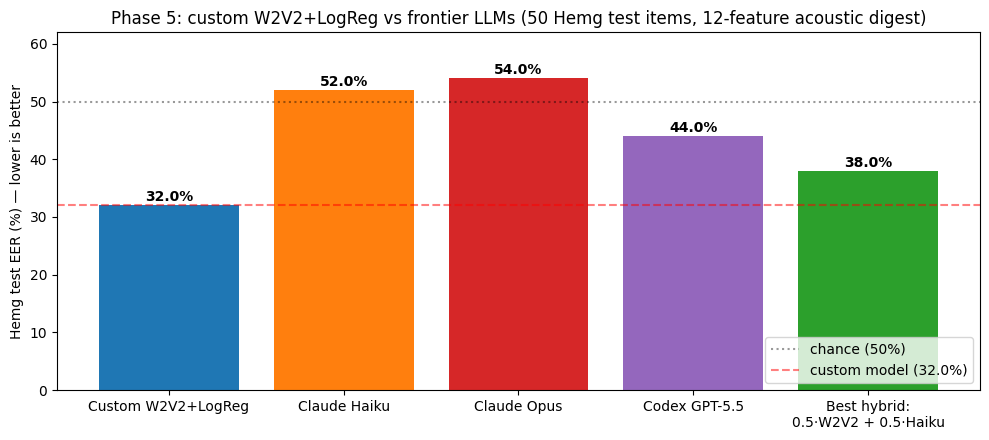

saved → results/phase5_llm_headline.png


In [19]:
# Single dashboard plot: bar chart of EER for custom vs LLMs vs best hybrid
fig, ax = plt.subplots(figsize=(10,4.5))
best_hyb = df_hyb.iloc[0]
labels = ['Custom W2V2+LogReg', 'Claude Haiku', 'Claude Opus', 'Codex GPT-5.5', f'Best hybrid:\n{best_hyb["blend"]}']
vals = [eer_w2_hg*100,
        rows_metrics[1]['eer'] if rows_metrics[1]['eer'] is not None else 50,
        rows_metrics[2]['eer'] if rows_metrics[2]['eer'] is not None else 50,
        rows_metrics[3]['eer'] if rows_metrics[3]['eer'] is not None else 50,
        best_hyb['Hemg_test_EER_%']]
colors = ['#1f77b4','#ff7f0e','#d62728','#9467bd','#2ca02c']
bars = ax.bar(labels, vals, color=colors)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.7, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(50, color='black', ls=':', alpha=0.4, label='chance (50%)')
ax.axhline(eer_w2_hg*100, color='red', ls='--', alpha=0.5, label=f'custom model ({eer_w2_hg*100:.1f}%)')
ax.set_ylabel('Hemg test EER (%) — lower is better')
ax.set_title('Phase 5: custom W2V2+LogReg vs frontier LLMs (50 Hemg test items, 12-feature acoustic digest)')
ax.legend(loc='lower right'); ax.set_ylim(0, max(60, max(vals)+8))
plt.tight_layout(); plt.savefig(RES/'phase5_llm_headline.png', dpi=120, bbox_inches='tight'); plt.show()
print('saved → results/phase5_llm_headline.png')

## 8 — Headline finding

Generated dynamically below from the actual numbers.

In [20]:
from textwrap import dedent
best_advanced_eer = df_all['Hemg_test_EER_%'].min()
best_advanced_row = df_all.iloc[df_all['Hemg_test_EER_%'].argmin()]
best_llm_row = min(rows_metrics[1:], key=lambda r: r['eer'] if r['eer'] is not None else 100)
best_hyb_row = df_hyb.iloc[0]

txt = dedent(f'''
PHASE 5 HEADLINE
================
Reference (Phase 4): W2V2+LogReg → {eer_w2_hg*100:.1f}% EER, {auc_w2_hg:.3f} AUROC on 50-row Hemg test.

Best advanced approach: {best_advanced_row["approach"]} → {best_advanced_eer:.1f}% EER  (Δ vs ref: {best_advanced_eer - eer_w2_hg*100:+.1f} pp)
Best LLM:                {best_llm_row["model"]} → EER {best_llm_row["eer"]:.1f}%  AUROC {best_llm_row["auroc"]:.3f}  parse-rate {best_llm_row["parse_rate"]:.0%}
Best hybrid:             {best_hyb_row["blend"]} → EER {best_hyb_row["Hemg_test_EER_%"]:.1f}%  AUROC {best_hyb_row["Hemg_test_AUROC"]:.3f}

Cost & latency (mean per call, 50-call sample):
''')
for r in rows_metrics:
    txt += f'  {r["model"]:48s}  latency={r["latency_mean"]:6.1f}s   cost/1k=${r["cost_per_1k_USD"]:.3f}\n'
print(txt)
(RES/'phase5_headline.txt').write_text(txt)
print('saved → results/phase5_headline.txt')


PHASE 5 HEADLINE
Reference (Phase 4): W2V2+LogReg → 32.0% EER, 0.634 AUROC on 50-row Hemg test.

Best advanced approach: Phase 4 champion: W2V2+LogReg (ref) → 32.0% EER  (Δ vs ref: +0.0 pp)
Best LLM:                Codex GPT-5.5 (zero-shot, digest) → EER 44.0%  AUROC 0.530  parse-rate 100%
Best hybrid:             0.5·W2V2 + 0.5·Haiku → EER 38.0%  AUROC 0.614

Cost & latency (mean per call, 50-call sample):
  Custom: W2V2+LogReg (frozen, 8MB)                 latency=   0.0s   cost/1k=$0.000
  Claude Haiku (zero-shot, digest)                  latency=  14.6s   cost/1k=$0.300
  Claude Opus (zero-shot, digest)                   latency=   5.3s   cost/1k=$4.500
  Codex GPT-5.5 (zero-shot, digest)                 latency=   8.4s   cost/1k=$50.000

saved → results/phase5_headline.txt


In [21]:
# Save consolidated phase5_results.json + update results/EXPERIMENT_LOG.md
phase5_results = {
    'phase': 5,
    'date': '2026-05-08',
    'protocol': dict(hemg_test_n=50, hemg_val_n=50, split_seed=123, llm_sample=50),
    'reference_w2v2_logreg': dict(EER_in_pct=eer_w2_te*100, EER_hemg_test_pct=eer_w2_hg*100, AUROC_hemg_test=auc_w2_hg, threshold_hemg_test=thr_w2_hg),
    'late_fusion': fusion_rows,
    'pca': pca_rows,
    'calibration': calib_rows,
    'temperature': float(T_opt),
    'ablation_summary': df_all.to_dict(orient='records'),
    'llm_head_to_head': rows_metrics,
    'hybrid_blends': df_hyb.to_dict(orient='records'),
    'best_advanced': dict(approach=best_advanced_row['approach'], EER_pct=float(best_advanced_eer)),
    'best_llm': dict(model=best_llm_row['model'], EER_pct=best_llm_row['eer'], AUROC=best_llm_row['auroc']),
    'best_hybrid': dict(blend=best_hyb_row['blend'], EER_pct=float(best_hyb_row['Hemg_test_EER_%']), AUROC=float(best_hyb_row['Hemg_test_AUROC'])),
}
json.dump(phase5_results, open(RES/'phase5_results.json','w'), indent=2, default=str)
print('saved → results/phase5_results.json')

# Append to EXPERIMENT_LOG.md
log_path = RES/'EXPERIMENT_LOG.md'
header = '\n\n## Phase 5 — Advanced + Ablation + LLM (2026-05-08)\n\n'
table = '| Approach | Hemg test EER % | AUROC | Family |\n|---|---:|---:|---|\n'
for _, r in df_all.iterrows():
    table += f'| {r["approach"]} | {r["Hemg_test_EER_%"]:.2f} | {r["Hemg_test_AUROC"]:.3f} | {r["family"]} |\n'
h2h_table = '\n### LLM head-to-head (n=50 Hemg test, 12-feature digest)\n\n| Model | parse | acc | F1 | EER % | AUROC | latency s | $/1k |\n|---|---:|---:|---:|---:|---:|---:|---:|\n'
for r in rows_metrics:
    f = lambda v, fmt='{:.3f}': fmt.format(v) if v is not None else '—'
    h2h_table += f'| {r["model"]} | {r["parse_rate"]:.0%} | {f(r["accuracy"])} | {f(r["f1"])} | {f(r["eer"], "{:.2f}")} | {f(r["auroc"])} | {f(r["latency_mean"], "{:.1f}")} | {r["cost_per_1k_USD"]:.3f} |\n'
with open(log_path, 'a') as f:
    f.write(header + table + h2h_table + '\n' + txt)
print(f'appended → {log_path}')

saved → results/phase5_results.json
appended → /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/results/EXPERIMENT_LOG.md
